# Semifinal 01 - Exploratory analysis of the full 2024 election tweet dataset (activity over time, duplicates, domains)

In [ ]:
DATA_DIR = "../../data/semifinal"

In [1]:
import os
import requests

ValueError: mount failed

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv(f'{DATA_DIR}/encrypted_merge.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9817355 entries, 0 to 9817354
Data columns (total 12 columns):
 #   Column        Dtype  
---  ------        -----  
 0   created_at    object 
 1   username      object 
 2   tcode         object 
 3   num_retweets  int64  
 4   type          object 
 5   frn_cnt       float64
 6   flw_cnt       float64
 7   sts_cnt       float64
 8   loc           object 
 9   lst_cnt       float64
 10  content       object 
 11  lang          object 
dtypes: float64(4), int64(1), object(7)
memory usage: 898.8+ MB


In [8]:
df['tcode'].value_counts()

tcode
rt         6497711
mention    2121754
reply      1197890
Name: count, dtype: int64

In [ ]:
import pandas as pd

# Misalkan df adalah DataFrame yang kamu miliki
grouped_df = df.groupby(['frn_cnt', 'flw_cnt', 'sts_cnt'])['content'].count().reset_index(name='count')

# Mengurutkan berdasarkan jumlah terbanyak
sorted_df = grouped_df.sort_values(by='count', ascending=False)

sorted_df

          frn_cnt   flw_cnt    sts_cnt  count
0             0.0       0.0        0.0   1616
2             0.0       0.0        2.0    536
5             0.0       0.0        5.0    461
3             0.0       0.0        3.0    455
13            0.0       0.0       13.0    451
...           ...       ...        ...    ...
1871584     171.0      41.0     1024.0      1
1871585     171.0      41.0     1094.0      1
1871586     171.0      41.0     1320.0      1
1871588     171.0      41.0     2349.0      1
4306068  259226.0  810882.0  2415060.0      1

[4306069 rows x 4 columns]

In [ ]:
filtered_df = df[(df['frn_cnt'] == 84) & (df['flw_cnt'] == 258) & (df['sts_cnt'] == 31515)]

In [ ]:
filtered_df.head()

                   created_at                                       username  \
1968813  2024-01-16T07:02:36Z  @QXvmpQH5zZGCDPypLQdX+eskrOsavwRUghNP2Ys2/Go=   
1968820  2024-01-16T07:02:37Z  @kdrcWmsZq7XOtN+NBgWPlsGXAPOK6qlz6wQB2rcYqu0=   
1968827  2024-01-16T07:02:38Z  @zDWnImM1cYonU5zPYiEQBymGjhZ0fCqmL/A1HHL91Xo=   
1968837  2024-01-16T07:02:39Z  @LED5pt9eVJqOzhRG5Mvwjx3l7oPlnJ8Kd9Jqsl9gMh0=   
1968846  2024-01-16T07:02:40Z  @H92DEzGrBSdVw2q8vOpTOJF+LbhRVSk8NRKBguIILnI=   

           tcode  num_retweets  type  frn_cnt  flw_cnt  sts_cnt  \
1968813  mention             0  twit     84.0    258.0  31515.0   
1968820    reply             0  twit     84.0    258.0  31515.0   
1968827    reply             0  twit     84.0    258.0  31515.0   
1968837    reply             0  twit     84.0    258.0  31515.0   
1968846    reply             0  twit     84.0    258.0  31515.0   

                                 loc  lst_cnt  \
1968813  ÃT: -6.2343885,106.7582603      0.0   
1968820  ÃT: -6.2

In [ ]:
import pandas as pd

# Misalkan df adalah DataFrame yang kamu miliki

# Hitung jumlah baris sebelum penghapusan duplikat
count_before = len(df)
print("Jumlah baris sebelum penghapusan duplikat:", count_before)

# Hapus duplikat berdasarkan kolom 'content'
df_no_duplicates = df.drop_duplicates(subset=['content'])

# Hitung jumlah baris setelah penghapusan duplikat
count_after = len(df_no_duplicates)
print("Jumlah baris setelah penghapusan duplikat:", count_after)

Jumlah baris sebelum penghapusan duplikat: 9817355
Jumlah baris setelah penghapusan duplikat: 4062375


In [ ]:
# Mengelompokkan berdasarkan 'content' dan menghitung jumlah kemunculannya
content_counts = df['content'].value_counts()

# Mencari konten dengan jumlah duplikat terbanyak
most_duplicated_content = content_counts.idxmax()
max_count = content_counts.max()

In [ ]:
print(f"Konten dengan jumlah duplikat terbanyak: '{most_duplicated_content}'")
print(f"Jumlah duplikat: {max_count}")

Konten dengan jumlah duplikat terbanyak: 'RT Anies di acaranya mengajak penonton berlatih berpikir kritis dan ngajarin cara memahami data Meanwhile, prabowo di acaranya bikin penontonnya goblok-goblokin orang Tau kan sekarang mana yg berusaha mencerdaskan bangsa dan yg mendorong kemunduran bangsa https://t.co/BtCa6JMaxV [RE madarkham]'
Jumlah duplikat: 12421


In [ ]:
df_most_duplicated = df[df['content'] == most_duplicated_content]

In [ ]:
filtered_df = df_most_duplicated[df_most_duplicated['tcode'] != 'rt']

In [ ]:
df_most_duplicated['tcode'].value_counts()

tcode
rt    12421
Name: count, dtype: int64

In [ ]:
filtered_df = df[(df['frn_cnt'] == 84) & (df['flw_cnt'] == 259) & (df['sts_cnt'] == 33404)]

In [ ]:
filtered_df

                   created_at                                       username  \
5958947  2024-01-25T04:53:16Z  @GDh22Qyzk4pTo39zJr0eEeJ/IVeomzEe/2WpeBs5Fqk=   
5958949  2024-01-25T04:53:16Z  @Z8YXmqFjmUCMpV37Ba3qNcKNpZ4nFMoM29h0EMADr1c=   
5958951  2024-01-25T04:53:17Z  @6P4kw+V8XBEnIQAh8BjaoMYCzqZ8mKlovQeoBZUgjFE=   
5958952  2024-01-25T04:53:17Z  @L0NwaT+Q/mXuQEuyzKDuiP73snTjxZQRcwXxSvgbAOA=   
5958957  2024-01-25T04:53:18Z  @MTIdOiMv2j6dsgyWrwVJPFXXAWclddKvP5CIlMVHMd0=   
...                       ...                                            ...   
7519604  2024-01-25T04:53:13Z  @6TelIz56TsxNQq2NvE+aNA6jUPLdOFbXgzD601Kj2JY=   
7519605  2024-01-25T04:53:13Z  @vpSxvuVcaQpxNV11J4irOmFYuZnyIHsqHrAX/UQMJtM=   
7519607  2024-01-25T04:53:14Z  @6Zok38bkzQvaBP8qi95MC/4Bg3VgWhHp5QFJbY6m/6M=   
7519609  2024-01-25T04:53:14Z  @tOM0GPiJYoUM/jk7MPcQyYrZ8qWMeJ6oQDDQLxkcB9E=   
7519612  2024-01-25T04:53:15Z  @pjpBSMHvlQmXIL5bCiYr+aI7aQVM6LBL/LbKkd86uyI=   

         tcode  num_retweets  type  frn

In [ ]:
sorted_df.to_csv(f"{DATA_DIR}/account_info.csv", index=False)

In [ ]:
df_sample = df.sample(n = 5000)

In [ ]:
df_sample.to_csv(f"{DATA_DIR}/sample_first.csv", index=False)

In [ ]:
df['tcode'].value_counts()

tcode
rt         6497711
mention    2121754
reply      1197890
Name: count, dtype: int64

# Sample

In [ ]:
# df = pd.read_csv(f'{DATA_DIR}/samplesatdat.csv')

In [ ]:
df.head()

             created_at                                       username tcode  \
0  2024-01-04T09:57:09Z  @QOS7XYPBfXZWFeLSmdLEt8njUMwwr2Fpel3Cqvh2gW4=    rt   
1  2024-01-04T09:57:09Z  @lSDenDKpcZVnv9txjBcg5qaqxYgVAq/3gTvA8yxPuL4=    rt   
2  2024-01-04T09:57:10Z  @Ykjdr3xs5+WfH9zBQMoAx5fdTeAwmRRm28PFVw5JeJE=    rt   
3  2024-01-04T09:57:10Z  @KQ/OmqgBG/U/OVkvpqAQYYiAThFGxQBtg3J5Vjp4Glk=    rt   
4  2024-01-04T09:57:11Z  @yqECLRUCZgqx8VzEUl430Wj6mfh2SgDYzKwala0bT5o=    rt   

   num_retweets  type  frn_cnt  flw_cnt  sts_cnt             loc  lst_cnt  \
0          1248  twit    266.0    107.0   9687.0             NaN      0.0   
1           195  twit    564.0    303.0  12461.0  indonesia kaya      2.0   
2           116  twit    376.0    156.0   7488.0       Indonesia      1.0   
3          2264  twit    163.0    203.0   2065.0             NaN      0.0   
4          1157  twit      1.0      1.0    798.0             NaN      0.0   

                                             content lan

In [ ]:
df_reply = df[df['tcode'] == 'reply']

In [ ]:
df[df['username'] == '@5Tz753nhSrc3MyKUjKPGAKQ59HMT5TnaXVJrYBVFXro=']

,created_at,username,tcode,num_retweets,type,frn_cnt,flw_cnt,sts_cnt,loc,lst_cnt,content,lang


In [ ]:
df_reply['content'][92]

'Dan Pak Prabowo sendiri adalah keluarga Warga Nahdliyyin juga. Sejak 28 tahun yang lalu Pak Prabowo sudah menjadi Anggota Kehormatan Gerakan Pemuda Ansor, sehingga Pak Prabowo sangat dekat Ulama dan anak muda Nahdlatul Ulama. #PersatuanNasional https://t.co/fgKPrq9Rar'

In [ ]:
# Konversi kolom 'created_at' ke datetime
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

In [ ]:
tweet_per_day = df['created_at'].dt.date.value_counts().sort_index()

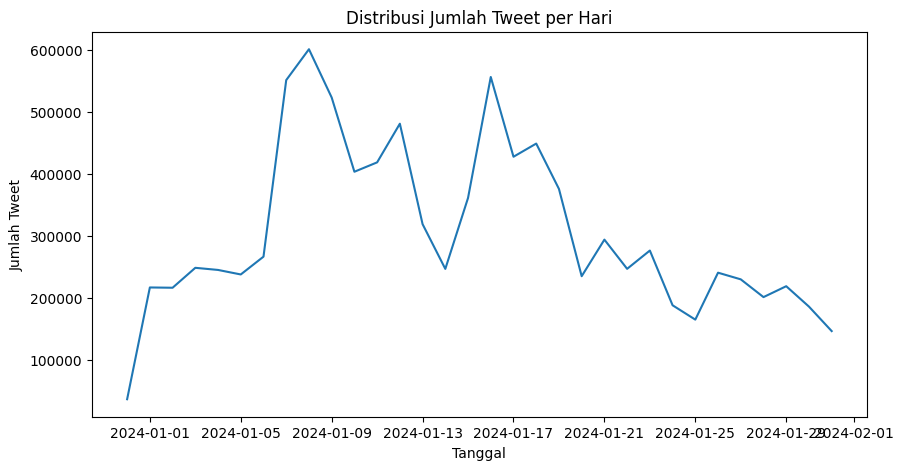

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
tweet_per_day.plot(kind='line')
plt.title('Distribusi Jumlah Tweet per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Tweet')
plt.show()

In [ ]:
peak_activity = tweet_per_day.idxmax()
peak_count = tweet_per_day.max()
print(f"Jumlah tweet tertinggi terjadi pada {peak_activity} dengan {peak_count} tweet.")

Jumlah tweet tertinggi terjadi pada 2024-01-08 dengan 600501 tweet.


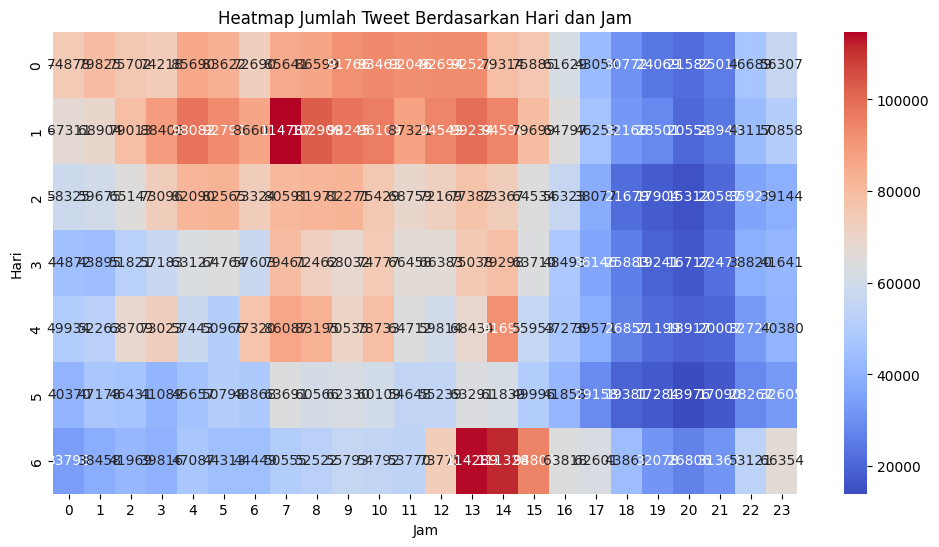

In [ ]:
import seaborn as sns

df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek
heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt='d')
plt.title('Heatmap Jumlah Tweet Berdasarkan Hari dan Jam')
plt.xlabel('Jam')
plt.ylabel('Hari')
plt.show()

In [ ]:
# Ekstraksi informasi jam
df['hour'] = df['created_at'].dt.hour
tweet_per_hour = df['hour'].value_counts().sort_index()

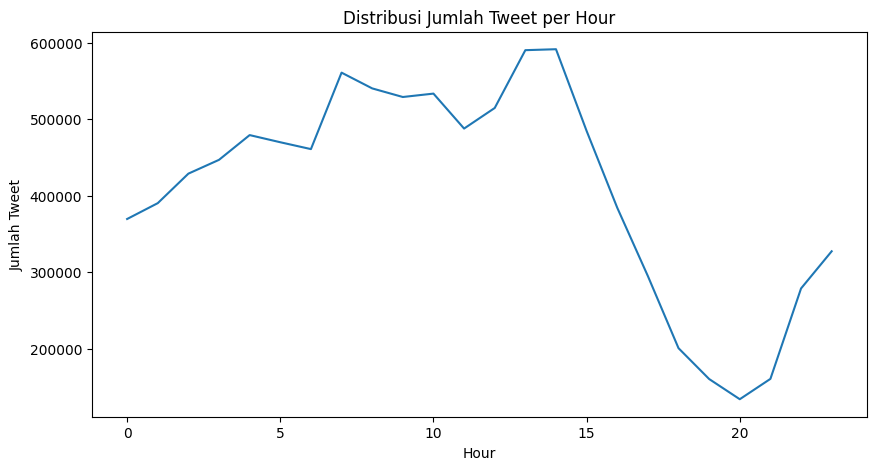

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
tweet_per_hour.plot(kind='line')
plt.title('Distribusi Jumlah Tweet per Hour')
plt.xlabel('Hour')
plt.ylabel('Jumlah Tweet')
plt.show()

In [ ]:
df['date'] = df['created_at'].dt.date
df['hour'] = df['created_at'].dt.hour

In [ ]:
tweet_per_hour_day = df.groupby(['date', 'hour']).size().unstack(fill_value=0)

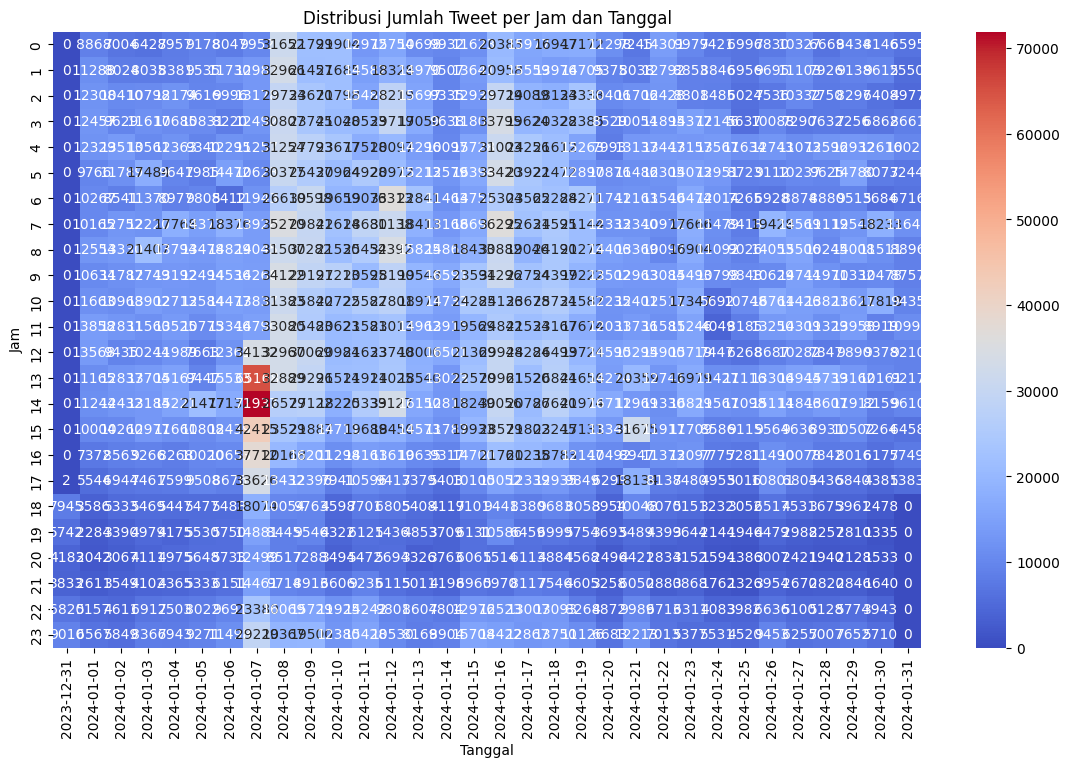

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(tweet_per_hour_day.T, cmap='coolwarm', annot=True, fmt='d')
plt.title('Distribusi Jumlah Tweet per Jam dan Tanggal')
plt.xlabel('Tanggal')
plt.ylabel('Jam')
plt.show()

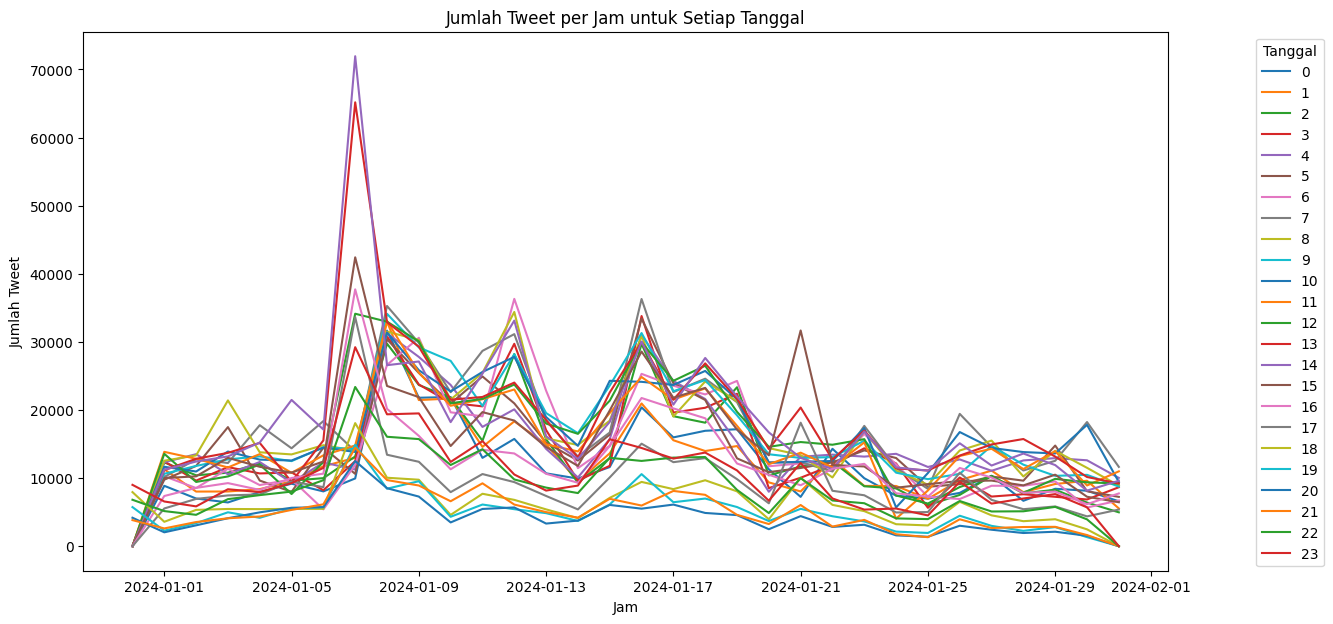

In [ ]:
tweet_per_hour_day.plot(kind='line', figsize=(14, 7))
plt.title('Jumlah Tweet per Jam untuk Setiap Tanggal')
plt.xlabel('Jam')
plt.ylabel('Jumlah Tweet')
plt.legend(title='Tanggal', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.show()

In [ ]:
import pandas as pd

# Filter tweet pada tanggal dan jam tertentu
df_filtered = df[(df['created_at'].dt.date == pd.to_datetime('2024-01-07').date()) &
                 (df['created_at'].dt.hour == 14)]

In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71937 entries, 8839613 to 9777354
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   created_at    71937 non-null  datetime64[ns, UTC]
 1   username      71935 non-null  object             
 2   tcode         71937 non-null  object             
 3   num_retweets  71937 non-null  int64              
 4   type          71937 non-null  object             
 5   frn_cnt       71937 non-null  float64            
 6   flw_cnt       71937 non-null  float64            
 7   sts_cnt       71937 non-null  float64            
 8   loc           35471 non-null  object             
 9   lst_cnt       71937 non-null  float64            
 10  content       71937 non-null  object             
 11  lang          71937 non-null  object             
 12  hour          71937 non-null  int32              
 13  day_of_week   71937 non-null  int32              
 14  dat

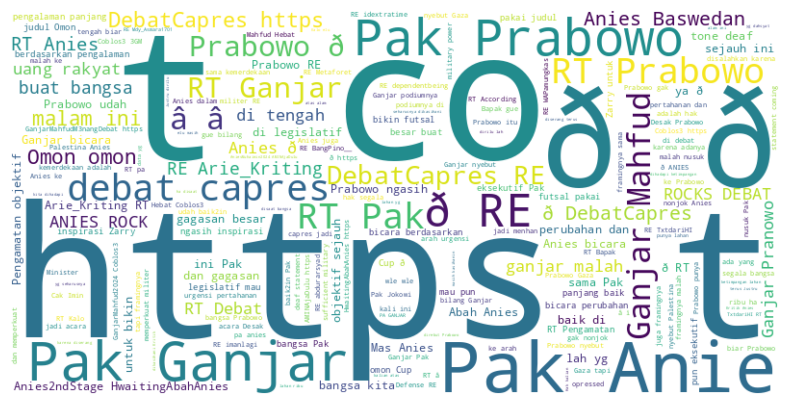

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua konten tweet menjadi satu string
text = ' '.join(df_filtered['content'].astype(str).tolist())

# Buat word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Tampilkan word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
# Cari tweet yang mengandung 'https'
df_https = df_filtered[df_filtered['content'].str.contains('https', na=False, case=False)]

In [ ]:
from urllib.parse import urlparse

# Fungsi untuk mengekstrak domain
def extract_domain(url):
    try:
        parsed_url = urlparse(url)
        return parsed_url.netloc
    except:
        return None

# Ekstrak domain dari tweet yang mengandung 'https'
df_https['domain'] = df_https['content'].apply(lambda x: extract_domain(x.split('https')[1].split()[0]) if 'https' in x else None)

# Hitung frekuensi kemunculan domain
domain_counts = df_https['domain'].value_counts()

# Tampilkan domain yang paling sering muncul
print(domain_counts.head(10))

domain
    22204
Name: count, dtype: int64


<ipython-input-26-ea61388b59a8>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_https['domain'] = df_https['content'].apply(lambda x: extract_domain(x.split('https')[1].split()[0]) if 'https' in x else None)


In [ ]:
df_https['domain'].value_counts()

domain
    22204
Name: count, dtype: int64

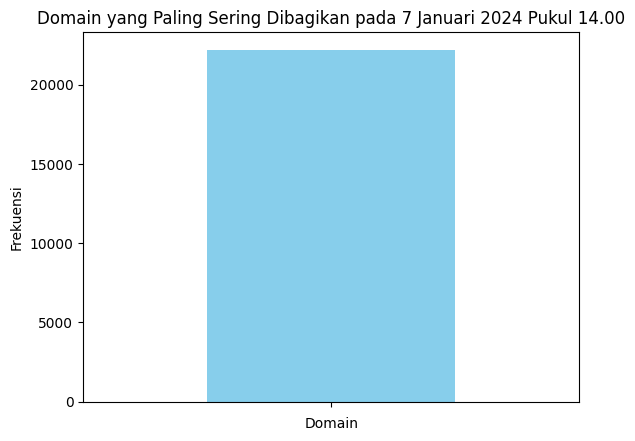

In [ ]:
import matplotlib.pyplot as plt

# Visualisasi frekuensi domain
domain_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Domain yang Paling Sering Dibagikan pada 7 Januari 2024 Pukul 14.00')
plt.xlabel('Domain')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df_https.head()

                       created_at  \
8839615 2024-01-07 14:40:08+00:00   
8839620 2024-01-07 14:40:08+00:00   
8839621 2024-01-07 14:40:08+00:00   
8839622 2024-01-07 14:40:08+00:00   
8839623 2024-01-07 14:40:08+00:00   

                                              username    tcode  num_retweets  \
8839615  @sIVyJzexyg//n7zFb1ubdLt4qO92CICzW/uWAh6oInE=       rt           991   
8839620  @S8m867JB3diNBPerw3Ytyy3XA1t+8fRBb0M0215ZY5A=       rt          2006   
8839621  @l0+fGzxTfdR8IkWzldKEv7GTp7GhNZJ2+wR6pMRBvg4=       rt            16   
8839622  @d2cANXuqXWeor/oMPtAslZUh4kf2G6gB5tCAlrNY7C4=  mention             0   
8839623  @3OT2FWNB/8u8z7ZDiRaTYxq2WdgDe9MfdbITeCTxjsw=       rt          1560   

         type  frn_cnt  flw_cnt  sts_cnt                    loc  lst_cnt  \
8839615  twit      4.0     84.0   1238.0  Bojonegoro, Indonesia      0.0   
8839620  twit     18.0      0.0     56.0                    NaN      0.0   
8839621  twit   1464.0    199.0   4834.0        Greater Jakart

In [ ]:
df_https['tcode'].value_counts()

tcode
rt         16888
mention     4970
reply        346
Name: count, dtype: int64

In [ ]:
df_https['content'][8839621]

'RT Apa yang terjadi ini? Susu terbang bertebaran di udara Jakarta? Kampanye siapa ini? Tak lain tak bukan: Prabowo - Gibran! Cihuyyyyyyy https://t.co/YT2R7zn3Yu [RE WaktunyaIDMaju]'

In [ ]:
df['type'].value_counts()

type
twit    9817355
Name: count, dtype: int64

In [ ]:
df[df['lang'] == 'pt']

,created_at,username,tcode,num_retweets,type,frn_cnt,flw_cnt,sts_cnt,loc,lst_cnt,content,lang


In [ ]:
df['content'][293923]

'RT PRABOWO KETAMPOL NETIZEN "Hanya orang \'BUTA HATI\' yang membiarkan pendukungnya bantÃ© orang ampai mati." #AsalBukanPrabowo https://t.co/CCDRcptYEU [RE denni_sauya]'

In [ ]:
df['lang'].value_counts()

lang
id    9817263
en         39
de         13
it         11
da          6
pt          5
tr          4
fi          4
sv          3
pl          2
sl          2
sq          2
ro          1
Name: count, dtype: int64

In [ ]:
df['content'][1010]

'@QuLKjQodmwLXGXeB2N2AgRduwohfY07Cn7thm3oLd68= Dengan kita memilih anies maka negara kita terselamatkan dari rezim oligarkiâ\x9d¤ï¸\x8f'